In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

Extracting Data from H5 

In [2]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt
# import re

# rng = np.random.default_rng(1234)

# filename = "nn_dineutron_spectrum.h5"
# L = 48.0
 
# punit = 2*np.pi/L
# punit2 = punit**2


# def boot_err(x):
#     return np.std(x[1:], ddof=1)


# def get_dE(g):
#     for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
#         if key in g:
#             return np.array(g[key])
#     raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


# def get_irrep(name):
#     return name.split("_Psq")[0]


# def get_Psq_total(name):
#     m = re.search(r"Psq(\d+)", name)
#     if m is None:
#         raise ValueError(f"Could not read total Psq from {name}")
#     return int(m.group(1))


# def get_level(name):
#     m = re.search(r"level(\d+)", name)
#     return int(m.group(1)) if m is not None else 0


# def dvec_from_d2(d2):
#     nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
#     best = None
#     for nx in range(nmax + 1):
#         for ny in range(nmax + 1):
#             for nz in range(nmax + 1):
#                 v = np.array([nx, ny, nz], dtype=int)
#                 if int(np.dot(v, v)) == int(d2):
#                     cand = tuple(sorted(v))
#                     if best is None or cand < best:
#                         best = cand
#     if best is None:
#         raise ValueError(f"No integer momentum representative found for Psq={d2}")
#     return np.array(best, dtype=int)


# raw_levels = []

# with h5py.File(filename, "r") as f:
#     mN = np.array(f["mN/E0"])
#     m = float(mN[0])

#     for name, g in f.items():
#         if name == "mN":
#             continue

#         irrep = get_irrep(name)
#         Psq_tot = get_Psq_total(name)
#         level_index = get_level(name)

#         N1 = int(np.array(g["Psq_N1"])[0])
#         N2 = int(np.array(g["Psq_N2"])[0])
#         dE = get_dE(g)

#         E1 = np.sqrt(mN**2 + punit2*N1)
#         E2 = np.sqrt(mN**2 + punit2*N2)
#         E_NN = dE + E1 + E2

#         E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot)
#         kstar2 = E_cm**2/4 - mN**2
#         q2 = kstar2/punit2

#         raw_levels.append({
#             "name": name,
#             "irrep": irrep,
#             "Psq_tot": Psq_tot,
#             "level_index": level_index,
#             "pair": tuple(sorted((N1, N2))),
#             "Ecm_boot": E_cm,
#             "q2_boot": q2,
#         })

# raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))
# print([r["Psq_tot"] for r in raw_levels])



F-Function

In [3]:
import itertools
from scipy import special as sp

'''
Finite-volume function
'''

twoPi = 2.0 * np.pi


# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * m **2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)


def inner1d(A, B):
   return np.sum( A * B, axis=1)


# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function( Ecm, nP, alpha, L):
    P = twoPi * nP / L                               # P = (2*pi/L)* nP
    P_sq = np.dot(P,P)                              # P^2
    E = np.sqrt( Ecm**2 + P_sq )                    # compute E given Ecm and P
    s = Ecm**2
    eps = 1e-16
    qcm = q_cm(s+1j*eps)
    qcm_sq = qcm**2
    rho = phase_space(s+1j*eps)
    beta = P/E                                      # boost velocity

    m_sq = m**2

    k = (twoPi / L) * intList
    omega = np.sqrt( m_sq + inner1d(k,k) )
    omega_cm, k_cm = lorentzBoost( omega, k, beta )
    tmp = cutoff( qcm_sq, inner1d(k_cm,k_cm), alpha, L ) * omega_cm / omega
    tmp = tmp / ( qcm_sq - inner1d(k_cm,k_cm ) )
    sum0 = ( xi / (2.0 * Ecm * L**3) ) * np.sum( tmp )

    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    z   = np.sqrt( alpha ) * qcm
    integral = ( xi / (4.0 * np.pi**2 * Ecm )) * ( ( np.sqrt( 0.25 * np.pi / alpha ) ) * np.exp( alpha * qcm_sq ) - 0.5 * np.pi * qcm * sp.erfi( z ) )

    return  1j * rho + sum0.real + integral # taking real part of sum to remove imaginary artifact at threshold



Various Constants

In [4]:
nShell = 15
alpha = 0.125
m = 1.0  #might need to be changed?

intList = generateIntList( nShell )

pole_gap = 2e-3

Psq_to_nP = {
    0:np.array([0,0,0]),
    1:np.array([0,0,1]),
    2:np.array([0,1,1]),
    3:np.array([1,1,1]),
    4:np.array([0,0,2])
}

L_values = [4,5,6]

E_min = 2.05
E_max = 4.2
Ecm_grid = np.linspace(E_min, E_max, 550)

a_r_Values = np.array([[1,1],[2,0]])


Cell 1 equivalent 

In [5]:
pole_cache = {}


def free_particle_poles(nP, L, m, E_min, E_max, maxShell=15):
    punit_ = 2*np.pi/L
    nP_arr = np.array(nP, dtype=float)
    Pvec = punit_*nP_arr
    P2_ = np.dot(Pvec, Pvec)
    levels = []
    for i in range(-maxShell, maxShell+1):
        for j in range(-maxShell, maxShell+1):
            for k in range(-maxShell, maxShell+1):
                n1 = np.array([i,j,k]); n2 = nP_arr - n1
                p1, p2 = punit_*n1, punit_*n2
                E_lab = np.sqrt(p1@p1+m**2) + np.sqrt(p2@p2+m**2)
                E_cm_sq = E_lab**2 - P2_
                if E_cm_sq <= 0:
                    continue
                E_cm = np.sqrt(E_cm_sq)
                if E_min - 0.05 < E_cm < E_max + 0.05:
                    levels.append(E_cm)
    return np.unique(np.round(levels, 10))


def free_particle_poles_cached(nP, L, m, E_min, E_max, maxShell=15):
    key = (tuple(nP), L, m, E_min, E_max, maxShell)
    if key not in pole_cache:
        raw = free_particle_poles(nP, L, m, E_min, E_max, maxShell)

        if len(raw) == 0:
            pole_cache[key] = raw
        else:
            unique = [raw[0]]
            for p in raw[1:]:
                if abs(p - unique[-1]) > 1e-5:
                    unique.append(p)
            pole_cache[key] = np.array(unique, dtype=float)
    print(key)
    return pole_cache[key]



In [6]:
def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)


def M_using_a_r(Ecm, a, r): 
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = (-1/a) + 0.5 * r * (qcm**2)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

def quantization_condition(Ecm, a, r, nP,L):
    # eps = 1e-16
    # s = Ecm**2 + 1j*eps
    # qCotDelta = -1/a + 0.5*r*q_cm(s)**2
    # Kinverse = xi * qCotDelta / (8*np.pi*Ecm)   <----- 2 ways to implment quantization condition. Comment out 1
    # Fpv = F_function(Ecm, nP, alpha, L).real   
    # return (Kinverse + Fpv).real
   
   
    FValues = F_function(Ecm,nP,alpha,L)
    MValues = M_using_a_r(Ecm,a,r)                 #<----- 2 ways to implment quantization condition. Comment out 1
    return np.real(1/MValues + FValues)

In [7]:
def find_zeros_in_grid(quantization_values, energies, poles,Psq):
    zeros = []
    for i in range(len(energies) - 1):
        f1, f2 = quantization_values[i], quantization_values[i+1]
        e1, e2 = energies[i], energies[i+1]
        if not (np.isfinite(f1) and np.isfinite(f2)):
            continue
        if np.sign(f1) == np.sign(f2):
            continue
        if np.any((poles >= e1) & (poles <= e2)):
            continue   
        # if(len(zeros)>= expected_zeros[Psq]):
        #     continue
        slope = (f2 - f1) / (e2 - e1)
        zeros.append(e1 - f1/slope)
    return np.array(zeros)


In [8]:
F_by_Psq = {}
for L in L_values:
    for Psq_tot, nP in Psq_to_nP.items():
        F_by_Psq[(L, Psq_tot)] = np.array([
            F_function(Ecm, nP, alpha, L) for Ecm in Ecm_grid
        ])

#test code, not ever used
# def spectrum_from_ar(a, r, L, Psq_tot):
#     Q = quantization_grid(a, r, L, Psq_tot)
#     poles = free_particle_poles_cached(Psq_to_nP[Psq_tot], L, m)
#     return find_zeros_in_grid(Q, Ecm_grid, poles, Psq_tot)

def quantization_grid(a, r, L, Psq_tot):
    M_values = M_using_a_r(Ecm_grid, a, r)
    F_values = F_by_Psq[(L, Psq_tot)]
    return np.real(1.0 / M_values + F_values)

In [9]:

sigma_E = 0.010 #the uncertainty, acts as noise
rng = np.random.default_rng()


def generate_spectrum(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
    rows = [] #the "observed" data, is noisy
    true_rows = [] #the actual data values, to check with.only exists for valdiation
    a,r = a_r_Values[i]

    for L in L_values:
        for Psq, nP in Psq_to_nP.items():
            Q = quantization_grid(a, r, L, Psq)
            poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
            E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

            for level_index, E_true in enumerate(E_true_levels):
                E_obs = E_true + rng.normal(0.0, sigma_E)       
                row = {
                    "L": float(L),
                    "Psq": Psq,
                    "level_index": level_index,
                    "E_true": float(E_true),
                    "E_obs": float(E_obs),
                    "dE": sigma_E,
                }

                rows.append(row)
                true_rows.append(row.copy())

    data = rows
    print(f"generated {len(data)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
    return data 


((np.int64(0), np.int64(0), np.int64(0)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(0)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(0)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 6, 1.0, 2.05, 4.2, 15)
generated 45 finite-volum

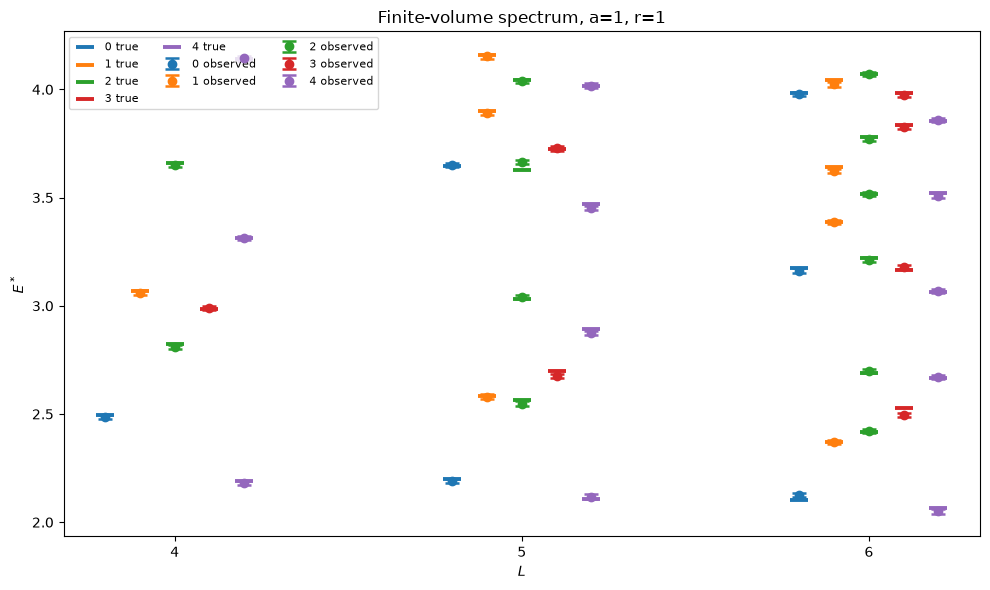

((np.int64(0), np.int64(0), np.int64(0)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 4, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(0)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 5, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(0)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(1), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(1), np.int64(1), np.int64(1)), 6, 1.0, 2.05, 4.2, 15)
((np.int64(0), np.int64(0), np.int64(2)), 6, 1.0, 2.05, 4.2, 15)
generated 48 finite-volum

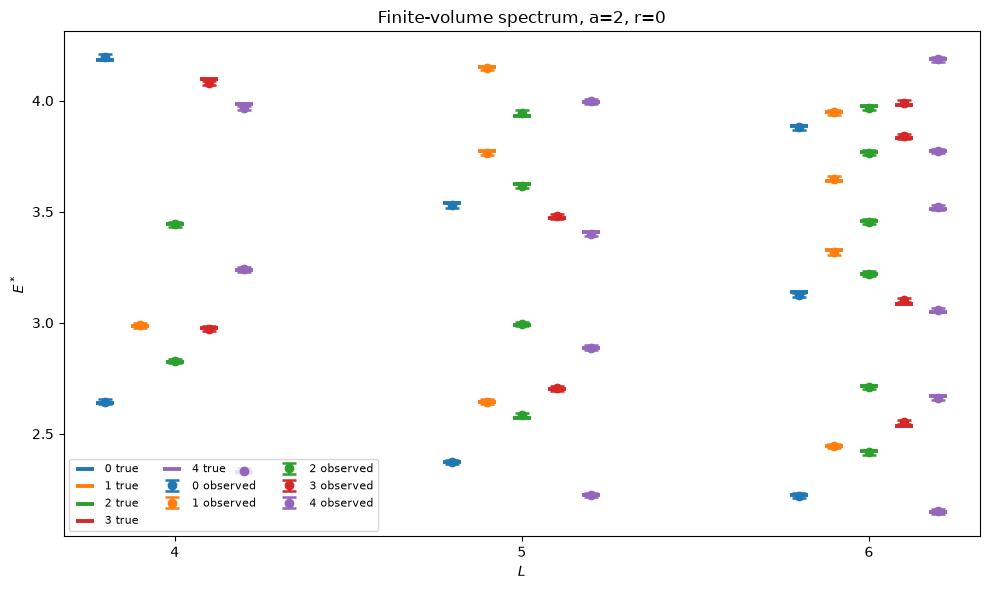

In [10]:
Psq_offsets = {0: -0.2, 1: -0.1, 2: 0.0, 3: 0.1, 4: 0.2}

def plot_spectrum(level_rows, i, include_observed=True, include_true=True, predicted_rows=None):
    plt.figure(figsize=(10, 6))
    for Psq in Psq_to_nP.keys():
        offset = Psq_offsets[Psq]
        rows_frame = [r for r in level_rows if r["Psq"] == Psq]

        if include_observed:
            x_obs = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_obs = np.array([r["E_obs"] for r in rows_frame], dtype=float)
            yerr = np.array([r["dE"] for r in rows_frame], dtype=float)

            plt.errorbar(
                x_obs,
                y_obs,
                yerr=yerr,
                fmt="o",
                markersize=6,
                capsize=5,
                capthick=1.8,
                elinewidth=1.8,
                linewidth=0,
                label=f"{Psq} observed",
                zorder=5,
            )

        if include_true:
            x_true = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_true = np.array([r["E_true"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_true,
                y_true,
                marker="_",
                s=180,
                linewidths=2.8,
                label=f"{Psq} true",
                zorder=4,
            )

    if predicted_rows is not None:
        for Psq in Psq_to_nP.keys():
            offset = Psq_offsets[Psq]
            rows_frame = [r for r in predicted_rows if r["Psq"] == Psq]
            x_pred = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_pred = np.array([r["E_pred"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_pred,
                y_pred,
                marker="x",
                s=70,
                linewidths=2.2,
                label=f"{Psq} GP",
                zorder=6,
            )

    plt.xticks(L_values, [str(int(L)) for L in L_values])
    plt.xlabel(r"$L$")
    plt.ylabel(r"$E^*$")
    plt.title(f"Finite-volume spectrum, a={a_r_Values[i][0]}, r={a_r_Values[i][1]}")

    plt.legend(ncols=3, fontsize=8)
    plt.tight_layout()
    plt.show()

data0 = generate_spectrum(0, L_values, Psq_to_nP, E_min, E_max, sigma_E)
plot_spectrum(data0, 0)

data1 = generate_spectrum(1, L_values, Psq_to_nP, E_min, E_max, sigma_E)
plot_spectrum(data1, 1)

In [14]:
def group_by_Psq(data, L):
    
    grouped = {Psq: [] for Psq in Psq_to_nP.keys()}
    for row in data:
        if row["L"] == float(L):
            grouped[row["Psq"]].append(row["E_true"])
    return {Psq: np.array(levels) for Psq, levels in grouped.items()}

for i in range(len(a_r_Values)):
    a, r = a_r_Values[i]
    data = data0 if i == 0 else data1
    print(f"\n=== a={a}, r={r} ===")
    for L in L_values:
        by_Psq = group_by_Psq(data, L)
        print(f"  L = {L}")
        for Psq, levels in by_Psq.items():
            print(f"    Psq={Psq}: {levels}")


=== a=1, r=1 ===
  L = 4
    Psq=0: [2.49676741]
    Psq=1: [3.07070516]
    Psq=2: [2.82375403 3.66000377]
    Psq=3: [2.9837403]
    Psq=4: [2.1888463  3.31313472 4.13835731]
  L = 5
    Psq=0: [2.20021952 3.64704779]
    Psq=1: [2.58533789 3.89883355 4.15869537]
    Psq=2: [2.56645904 3.03233308 3.62976565 4.04419434]
    Psq=3: [2.69749954 3.72386483]
    Psq=4: [2.10543787 2.89074587 3.47030543 4.01642772]
  L = 6
    Psq=0: [2.10089513 3.17575573 3.98257525]
    Psq=1: [2.37167177 3.38552705 3.64261136 4.04193094]
    Psq=2: [2.41734834 2.69164457 3.22260626 3.51695355 3.77804891 4.07094667]
    Psq=3: [2.52852784 3.1650867  3.83776602 3.98150133]
    Psq=4: [2.06348748 2.66427132 3.06580826 3.52250293 3.85621293]

=== a=2, r=0 ===
  L = 4
    Psq=0: [2.63766222 4.18193229]
    Psq=1: [2.98596602]
    Psq=2: [2.8239704  3.44541903]
    Psq=3: [2.97488759 4.09608842]
    Psq=4: [2.32946428 3.23676077 3.98467243]
  L = 5
    Psq=0: [2.37107059 3.53845932]
    Psq=1: [2.64457828 3.